# Book Comparison: Context Influence on Language Model Predictions

## Comparing *The Diary of Anne Frank* vs *Becoming* by Michelle Obama

This notebook extracts text from two PDF books, cleans and sentence-splits them,
randomly samples 500 sentences from each, and runs the full context-influence
analysis pipeline (perplexity, entropy, surprisal, independent t-tests,
context ablation, and visualizations).

---
## 0. Setup and Imports

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import AutoModelForCausalLM, AutoTokenizer
from typing import Dict, List, Set, Tuple, Optional
from collections import defaultdict
from tqdm.auto import tqdm
import json
import re
import warnings
import random
import PyPDF2
import nltk
from nltk.tokenize import sent_tokenize

warnings.filterwarnings('ignore')
nltk.download('punkt_tab', quiet=True)

# Reproducibility
random.seed(42)
np.random.seed(42)

# Auto-detect GPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("Using Apple MPS")
else:
    DEVICE = torch.device('cpu')
    print("Using CPU")

print(f"Device: {DEVICE}")

Using CPU
Device: cpu


---
## 1. Load Language Model

In [2]:
MODEL_NAME = 'gpt2'

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print(f"Loaded {MODEL_NAME} ({sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters)")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")

Loading gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded gpt2 (124M parameters)
Vocabulary size: 50,257 tokens


---
## 2. Core Metric Functions

Identical to the original context_influence_toolkit.

In [3]:
def compute_entropy_and_surprisal(logits: torch.Tensor, actual_token_id: int) -> Tuple[float, float]:
    probs = torch.softmax(logits, dim=-1)
    log_probs = torch.log2(probs + 1e-10)
    entropy = -(probs * log_probs).sum().item()
    actual_prob = probs[actual_token_id].item()
    surprisal = -np.log2(actual_prob + 1e-10)
    return entropy, surprisal


def compute_perplexity(model, tokenizer, text: str, device=DEVICE) -> float:
    inputs = tokenizer(text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
    return torch.exp(outputs.loss).item()


def process_text_full_metrics(model, tokenizer, text: str, device=DEVICE) -> Dict:
    encoding = tokenizer(
        text, return_tensors='pt', return_offsets_mapping=True,
        add_special_tokens=False
    )
    input_ids = encoding['input_ids'].to(device)
    offset_mapping = encoding['offset_mapping'][0].tolist()

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        logits = outputs.logits

    token_entropies = []
    token_surprisals = []
    for i in range(input_ids.shape[1] - 1):
        next_token_logits = logits[0, i, :]
        actual_next_token = input_ids[0, i + 1].item()
        entropy, surprisal = compute_entropy_and_surprisal(next_token_logits, actual_next_token)
        token_entropies.append(entropy)
        token_surprisals.append(surprisal)

    words = text.split()
    word_starts = []
    word_ends = []
    pos = 0
    for w in words:
        idx = text.index(w, pos)
        word_starts.append(idx)
        word_ends.append(idx + len(w))
        pos = idx + len(w)

    word_to_token_metrics = defaultdict(lambda: {'entropies': [], 'surprisals': []})
    for tok_idx, (tok_start, tok_end) in enumerate(offset_mapping[:-1]):
        if tok_idx >= len(token_entropies):
            break
        for w_idx in range(len(word_starts)):
            if tok_start < word_ends[w_idx] and tok_end > word_starts[w_idx]:
                word_to_token_metrics[w_idx]['entropies'].append(token_entropies[tok_idx])
                word_to_token_metrics[w_idx]['surprisals'].append(token_surprisals[tok_idx])
                break

    word_entropies = []
    word_surprisals = []
    for w_idx in range(len(words)):
        if w_idx in word_to_token_metrics and word_to_token_metrics[w_idx]['entropies']:
            word_entropies.append(np.mean(word_to_token_metrics[w_idx]['entropies']))
            word_surprisals.append(np.mean(word_to_token_metrics[w_idx]['surprisals']))
        else:
            word_entropies.append(np.nan)
            word_surprisals.append(np.nan)

    return {
        'text': text,
        'words': words,
        'n_tokens': len(token_entropies),
        'n_words': len(words),
        'perplexity': torch.exp(outputs.loss).item(),
        'mean_entropy': np.mean(token_entropies) if token_entropies else 0,
        'mean_surprisal': np.mean(token_surprisals) if token_surprisals else 0,
        'token_entropies': token_entropies,
        'token_surprisals': token_surprisals,
        'word_entropies': word_entropies,
        'word_surprisals': word_surprisals,
        'mean_word_entropy': float(np.nanmean(word_entropies)) if word_entropies else 0,
        'mean_word_surprisal': float(np.nanmean(word_surprisals)) if word_surprisals else 0,
    }


def is_word_start_token(tokenizer, token_id: int) -> bool:
    token_str = tokenizer.decode([token_id])
    if token_str in ['<|endoftext|>', '<unk>', '<pad>']:
        return False
    return token_str.startswith(' ') or token_str.startswith('\n')


def get_word_from_token(tokenizer, token_id: int) -> Optional[str]:
    if not is_word_start_token(tokenizer, token_id):
        return None
    token_str = tokenizer.decode([token_id])
    return token_str.strip().lower().strip('.,!?;:\'\"-()')


def compute_class_mass(
    model, tokenizer, context: str, target_words: Set[str],
    top_k: int = 1000, device=DEVICE
) -> float:
    inputs = tokenizer(context, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[0, -1, :]
    probs = torch.softmax(logits, dim=-1)
    top_k_probs, top_k_ids = torch.topk(probs, min(top_k, len(probs)))
    mass = 0.0
    for prob_val, token_id in zip(top_k_probs, top_k_ids):
        word = get_word_from_token(tokenizer, token_id.item())
        if word is not None and word in target_words:
            mass += prob_val.item()
    return mass


DEMO_VERBS = {
    'be', 'have', 'do', 'go', 'get', 'make', 'know', 'take', 'see', 'come',
    'want', 'use', 'find', 'give', 'tell', 'work', 'call', 'try', 'ask', 'need',
    'feel', 'leave', 'put', 'keep', 'let', 'begin', 'help', 'show', 'hear', 'play',
    'run', 'move', 'live', 'believe', 'bring', 'write', 'sit', 'stand', 'lose', 'pay',
    'study', 'build', 'learn', 'change', 'understand', 'create', 'speak', 'read',
}

print("Core metric functions loaded.")

Core metric functions loaded.


---
## 3. Extract Text from PDFs

In [4]:
def extract_pdf_text(filepath: str) -> str:
    """Extract all text from a PDF file."""
    reader = PyPDF2.PdfReader(filepath)
    pages_text = []
    for page in reader.pages:
        text = page.extract_text()
        if text:
            pages_text.append(text)
    return '\n'.join(pages_text)


raw_anne_frank = extract_pdf_text('Anne Frank.pdf')
raw_becoming = extract_pdf_text('Becoming Michelle.pdf')

print(f"Anne Frank raw text: {len(raw_anne_frank):,} characters")
print(f"Becoming raw text:   {len(raw_becoming):,} characters")
print(f"\nAnne Frank first 500 chars:\n{raw_anne_frank[:500]}")
print(f"\nBecoming first 500 chars:\n{raw_becoming[:500]}")

Anne Frank raw text: 559,167 characters
Becoming raw text:   929,723 characters

Anne Frank first 500 chars:
THE	DIARY	OF
	A	YOUNG	GIRL	:
THE
	DEFINITIVE	EDITION
	
Anne	Frank
	Edited	by	Otto	H.	Frank	and	Mirjam	Pressler
Translated	by	Susan	Massotty
TABLE	OF	CONTENTS
FOREWORD
SUNDAY,	JUNE	14,	1942
MONDAY,	JUNE	15,	1942
SATURDAY,	JUNE	20,1942
SATURDAY,	JUNE	20,	1942
SUNDAY,	JUNE	21,	1942
WEDNESDAY,	JUNE	24,	1942
WEDNESDAY,	JULY	1,	1942
SUNDAY,	JULY	5,	1942
WEDNESDAY,	JULY	8,	1942
THURSDAY,	JULY	9,	1942
FRIDAY,	JULY	10,	1942
SATURDAY,	JULY	11,	1942
SUNDAY,	JULY	12,	1942
FRIDAY,	AUGUST	14,	1942
FRIDAY,	AUG

Becoming first 500 chars:
https://T.me/amazhonbook https://T.me/amazhonbook 
Copyright © 2018 by Michelle Obama
All rights reserved.
Published in the United States by Crown, an imprint of the Crown Publishing Group, 
a division of Penguin Random House LLC, New York.
crownpublishing.com
CROWN and the Crown colophon are registered trademarks of Penguin Random House LLC.
Photograph credits

---
## 4. Clean Text: Remove Page Numbers, Headers, Footers, Non-Body Text

In [5]:
def clean_book_text(raw_text: str) -> str:
    """
    Clean extracted PDF text by removing:
    - Page numbers (standalone numbers on their own line)
    - Common headers/footers (book titles, author names repeated)
    - Table of contents lines
    - Chapter headings (kept minimal, just removed as non-body)
    - Excessive whitespace and artifacts
    """
    lines = raw_text.split('\n')
    cleaned_lines = []

    for line in lines:
        stripped = line.strip()

        # Skip empty lines
        if not stripped:
            continue

        # Skip standalone page numbers (just digits, possibly with dots/dashes)
        if re.match(r'^[\d\s\-\.]+$', stripped) and len(stripped) < 10:
            continue

        # Skip lines that are just roman numerals (chapter numbers, front matter)
        if re.match(r'^[ivxlcdmIVXLCDM]+\.?$', stripped):
            continue

        # Skip common header/footer patterns
        lower = stripped.lower()
        skip_patterns = [
            r'^page\s+\d+',
            r'^\d+\s*$',
            r'^chapter\s+[\divxlc]+',
            r'^part\s+[\divxlc]+',
            r'^table of contents',
            r'^copyright',
            r'^all rights reserved',
            r'^isbn',
            r'^published by',
            r'^printed in',
            r'^library of congress',
            r'^first edition',
            r'^acknowledgments$',
            r'^dedication$',
            r'^epilogue$',
            r'^prologue$',
            r'^foreword$',
            r'^preface$',
            r'^introduction$',
            r'^appendix',
            r'^notes$',
            r'^index$',
            r'^bibliography$',
            r'^about the author',
        ]
        if any(re.match(pat, lower) for pat in skip_patterns):
            continue

        # Skip very short lines that look like headers/footers (< 4 chars, not sentence fragments)
        if len(stripped) < 4 and not stripped[-1] in '.!?,':
            continue

        cleaned_lines.append(stripped)

    text = ' '.join(cleaned_lines)

    # Fix common PDF extraction artifacts
    text = re.sub(r'\s+', ' ', text)           # Multiple spaces -> single
    text = re.sub(r'\s*-\s*\n\s*', '', text)   # Hyphenated line breaks
    text = re.sub(r'\s*\.\s*\.\s*\.\s*', '... ', text)  # Fix ellipses
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', '', text)  # Control chars

    return text.strip()


clean_anne = clean_book_text(raw_anne_frank)
clean_becoming = clean_book_text(raw_becoming)

print(f"Anne Frank cleaned: {len(clean_anne):,} characters")
print(f"Becoming cleaned:   {len(clean_becoming):,} characters")
print(f"\nAnne Frank sample (first 500 chars):\n{clean_anne[:500]}")
print(f"\nBecoming sample (first 500 chars):\n{clean_becoming[:500]}")

Anne Frank cleaned: 558,654 characters
Becoming cleaned:   917,231 characters

Anne Frank sample (first 500 chars):
THE DIARY OF A YOUNG GIRL : DEFINITIVE EDITION Anne Frank Edited by Otto H. Frank and Mirjam Pressler Translated by Susan Massotty TABLE OF CONTENTS SUNDAY, JUNE 14, 1942 MONDAY, JUNE 15, 1942 SATURDAY, JUNE 20,1942 SATURDAY, JUNE 20, 1942 SUNDAY, JUNE 21, 1942 WEDNESDAY, JUNE 24, 1942 WEDNESDAY, JULY 1, 1942 SUNDAY, JULY 5, 1942 WEDNESDAY, JULY 8, 1942 THURSDAY, JULY 9, 1942 FRIDAY, JULY 10, 1942 SATURDAY, JULY 11, 1942 SUNDAY, JULY 12, 1942 FRIDAY, AUGUST 14, 1942 FRIDAY, AUGUST 21, 1942 WEDNE

Becoming sample (first 500 chars):
https://T.me/amazhonbook https://T.me/amazhonbook Published in the United States by Crown, an imprint of the Crown Publishing Group, a division of Penguin Random House LLC, New York. crownpublishing.com CROWN and the Crown colophon are registered trademarks of Penguin Random House LLC. Photograph credits appear on this page Ebook ISBN Cover desi

---
## 5. Sentence Splitting and Sampling

In [6]:
def split_and_filter_sentences(text: str, min_words: int = 5, max_words: int = 60) -> List[str]:
    """
    Split text into sentences using NLTK, then filter:
    - Remove sentences shorter than min_words
    - Remove sentences longer than max_words (likely OCR artifacts)
    - Remove sentences that are mostly non-alphabetic
    """
    raw_sentences = sent_tokenize(text)
    filtered = []
    for sent in raw_sentences:
        sent = sent.strip()
        words = sent.split()
        n_words = len(words)

        if n_words < min_words or n_words > max_words:
            continue

        # At least 70% of characters should be alphabetic or spaces
        alpha_ratio = sum(c.isalpha() or c.isspace() for c in sent) / max(len(sent), 1)
        if alpha_ratio < 0.70:
            continue

        filtered.append(sent)

    return filtered


anne_sentences = split_and_filter_sentences(clean_anne)
becoming_sentences = split_and_filter_sentences(clean_becoming)

print(f"Anne Frank: {len(anne_sentences)} sentences after filtering")
print(f"Becoming:   {len(becoming_sentences)} sentences after filtering")

# Show some examples
print(f"\nAnne Frank sample sentences:")
for s in anne_sentences[:5]:
    print(f"  - {s[:100]}{'...' if len(s) > 100 else ''}")

print(f"\nBecoming sample sentences:")
for s in becoming_sentences[:5]:
    print(f"  - {s[:100]}{'...' if len(s) > 100 else ''}")

Anne Frank: 5591 sentences after filtering
Becoming:   7618 sentences after filtering

Anne Frank sample sentences:
  - Initially, she wrote it strictly for herself.
  - Then, one day in 1944, Gerrit Bolkestein, a member of the Dutch government in exile, announced in a ...
  - As an example, he specifically mentioned letters and diaries.
  - Impressed by this speech, Anne Frank decided that when the war was over she would publish a book bas...
  - She began rewriting and editing her diary, improving on the text, omitting passages she didn’t think...

Becoming sample sentences:
  - https://T.me/amazhonbook https://T.me/amazhonbook Published in the United States by Crown, an imprin...
  - crownpublishing.com CROWN and the Crown colophon are registered trademarks of Penguin Random House L...
  - To the loves of my life: Malia and Sasha, my two most precious peas, who are my reasons for being, a...
  - Contents Endpaper Photographs Becoming Me Becoming Us Photograph Insert Becoming More Ph

In [7]:
# ============================================================================
# RANDOM SAMPLING: 500 sentences from each book
# ============================================================================

SAMPLE_SIZE = 500

assert len(anne_sentences) >= SAMPLE_SIZE, \
    f"Not enough Anne Frank sentences: {len(anne_sentences)} < {SAMPLE_SIZE}"
assert len(becoming_sentences) >= SAMPLE_SIZE, \
    f"Not enough Becoming sentences: {len(becoming_sentences)} < {SAMPLE_SIZE}"

anne_sample = random.sample(anne_sentences, SAMPLE_SIZE)
becoming_sample = random.sample(becoming_sentences, SAMPLE_SIZE)

# Build the corpus with condition labels
corpus = []
for sent in anne_sample:
    corpus.append({'text': sent, 'condition': 'anne_frank'})
for sent in becoming_sample:
    corpus.append({'text': sent, 'condition': 'becoming_michelle'})

print(f"Corpus: {len(corpus)} items total")
print(f"  anne_frank:        {sum(1 for c in corpus if c['condition'] == 'anne_frank')}")
print(f"  becoming_michelle: {sum(1 for c in corpus if c['condition'] == 'becoming_michelle')}")

# Word count stats per condition
for cond in ['anne_frank', 'becoming_michelle']:
    wc = [len(c['text'].split()) for c in corpus if c['condition'] == cond]
    print(f"\n  {cond} word counts: mean={np.mean(wc):.1f}, median={np.median(wc):.1f}, "
          f"min={min(wc)}, max={max(wc)}")

Corpus: 1000 items total
  anne_frank:        500
  becoming_michelle: 500

  anne_frank word counts: mean=17.3, median=15.0, min=5, max=60

  becoming_michelle word counts: mean=20.4, median=19.0, min=5, max=59


---
## 6. Run Metrics on Full Corpus

In [8]:
# ============================================================================
# PROCESS ALL 1000 SENTENCES THROUGH GPT-2
# ============================================================================

all_results = []

for item in tqdm(corpus, desc="Processing corpus"):
    text = item['text']
    try:
        metrics = process_text_full_metrics(model, tokenizer, text)
        result = {
            'condition': item['condition'],
            'text': text,
            'perplexity': metrics['perplexity'],
            'mean_entropy': metrics['mean_entropy'],
            'mean_surprisal': metrics['mean_surprisal'],
            'mean_word_entropy': metrics['mean_word_entropy'],
            'mean_word_surprisal': metrics['mean_word_surprisal'],
            'n_tokens': metrics['n_tokens'],
            'n_words': metrics['n_words'],
        }
        all_results.append(result)
    except Exception as e:
        print(f"Error processing: {text[:50]}... -> {e}")
        continue

results_df = pd.DataFrame(all_results)

print(f"\nProcessed {len(results_df)} items.")
print(f"\nSummary by condition:")
print(results_df.groupby('condition')[[
    'perplexity', 'mean_word_entropy', 'mean_word_surprisal'
]].mean().round(2).to_string())

Processing corpus:   0%|          | 0/1000 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Processed 1000 items.

Summary by condition:
                   perplexity  mean_word_entropy  mean_word_surprisal
condition                                                            
anne_frank             127.83               6.33                 6.21
becoming_michelle      112.48               6.19                 6.12


---
## 7. Statistical Comparison: Independent t-tests (Welch's)

In [9]:
# ============================================================================
# STATISTICAL TESTS (Independent samples - Welch's t-test)
# ============================================================================

def independent_comparison(df: pd.DataFrame, condition_col: str, value_col: str,
                           cond_a: str, cond_b: str) -> Dict:
    a = df[df[condition_col] == cond_a][value_col].dropna().values
    b = df[df[condition_col] == cond_b][value_col].dropna().values

    if len(a) < 2 or len(b) < 2:
        return {'error': f'Not enough data (n_a={len(a)}, n_b={len(b)})'}

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    pooled_std = np.sqrt(((len(a) - 1) * np.var(a, ddof=1) +
                          (len(b) - 1) * np.var(b, ddof=1)) /
                         (len(a) + len(b) - 2))
    cohens_d = (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0

    try:
        u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    except ValueError:
        u_stat, u_p = 0, 1.0

    return {
        'metric': value_col,
        'condition_a': cond_a,
        'condition_b': cond_b,
        'n_a': len(a),
        'n_b': len(b),
        'mean_a': np.mean(a),
        'mean_b': np.mean(b),
        'std_a': np.std(a, ddof=1),
        'std_b': np.std(b, ddof=1),
        'mean_diff': np.mean(a) - np.mean(b),
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'mann_whitney_p': u_p,
        'significant_p05': p_value < 0.05,
    }


def apply_fdr_correction(p_values: List[float]) -> List[float]:
    n = len(p_values)
    if n == 0:
        return []
    indexed = sorted(enumerate(p_values), key=lambda x: x[1])
    corrected = [0.0] * n
    prev = 1.0
    for rank_minus_1 in range(n - 1, -1, -1):
        orig_idx, p = indexed[rank_minus_1]
        rank = rank_minus_1 + 1
        adjusted = min(prev, p * n / rank)
        corrected[orig_idx] = adjusted
        prev = adjusted
    return corrected


# Run comparisons
metrics_to_compare = ['perplexity', 'mean_word_entropy', 'mean_word_surprisal']
comparisons = []

for metric in metrics_to_compare:
    result = independent_comparison(
        results_df,
        condition_col='condition',
        value_col=metric,
        cond_a='anne_frank',
        cond_b='becoming_michelle',
    )
    comparisons.append(result)

comp_df = pd.DataFrame(comparisons)

if 'p_value' in comp_df.columns:
    comp_df['p_fdr'] = apply_fdr_correction(comp_df['p_value'].tolist())

print("Independent comparisons: anne_frank vs. becoming_michelle (Welch's t-test)")
print("=" * 75)
for _, row in comp_df.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else 'ns'
    print(f"\n{row['metric']}:")
    print(f"  Anne Frank (n={row['n_a']:.0f}):        mean={row['mean_a']:.3f}  sd={row['std_a']:.3f}")
    print(f"  Becoming (n={row['n_b']:.0f}):          mean={row['mean_b']:.3f}  sd={row['std_b']:.3f}")
    print(f"  Difference:  {row['mean_diff']:.3f}")
    print(f"  t = {row['t_stat']:.3f}, p = {row['p_value']:.4f} (FDR: {row['p_fdr']:.4f}) {sig}")
    print(f"  Cohen's d = {row['cohens_d']:.3f}")
    print(f"  Mann-Whitney p = {row['mann_whitney_p']:.4f}")

Independent comparisons: anne_frank vs. becoming_michelle (Welch's t-test)

perplexity:
  Anne Frank (n=500):        mean=127.830  sd=149.716
  Becoming (n=500):          mean=112.480  sd=159.669
  Difference:  15.350
  t = 1.568, p = 0.1172 (FDR: 0.1757) ns
  Cohen's d = 0.099
  Mann-Whitney p = 0.0023

mean_word_entropy:
  Anne Frank (n=500):        mean=6.334  sd=0.761
  Becoming (n=500):          mean=6.192  sd=0.733
  Difference:  0.142
  t = 3.014, p = 0.0026 (FDR: 0.0079) **
  Cohen's d = 0.191
  Mann-Whitney p = 0.0077

mean_word_surprisal:
  Anne Frank (n=500):        mean=6.212  sd=1.106
  Becoming (n=500):          mean=6.121  sd=1.013
  Difference:  0.090
  t = 1.347, p = 0.1783 (FDR: 0.1783) ns
  Cohen's d = 0.085
  Mann-Whitney p = 0.2942


---
## 8. Visualization

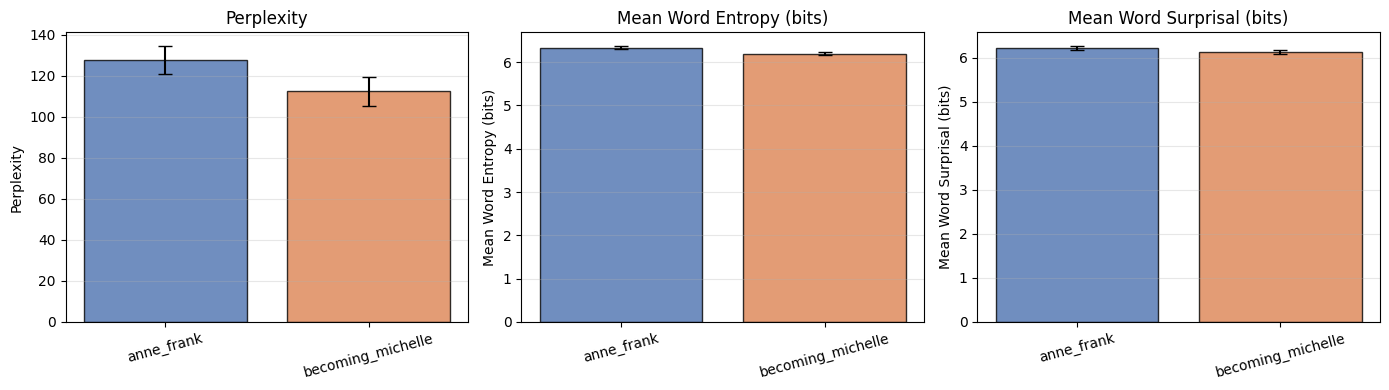

Saved: book_condition_comparison.png


In [10]:
# ============================================================================
# PLOT 1: Bar chart comparing conditions
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

for ax, metric, label in zip(axes, metrics_to_compare,
                              ['Perplexity', 'Mean Word Entropy (bits)', 'Mean Word Surprisal (bits)']):
    grouped = results_df.groupby('condition')[metric]
    means = grouped.mean()
    sems = grouped.sem()

    colors = [condition_colors.get(c, 'gray') for c in means.index]
    bars = ax.bar(means.index, means.values, yerr=sems.values,
                  capsize=5, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('book_condition_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: book_condition_comparison.png")

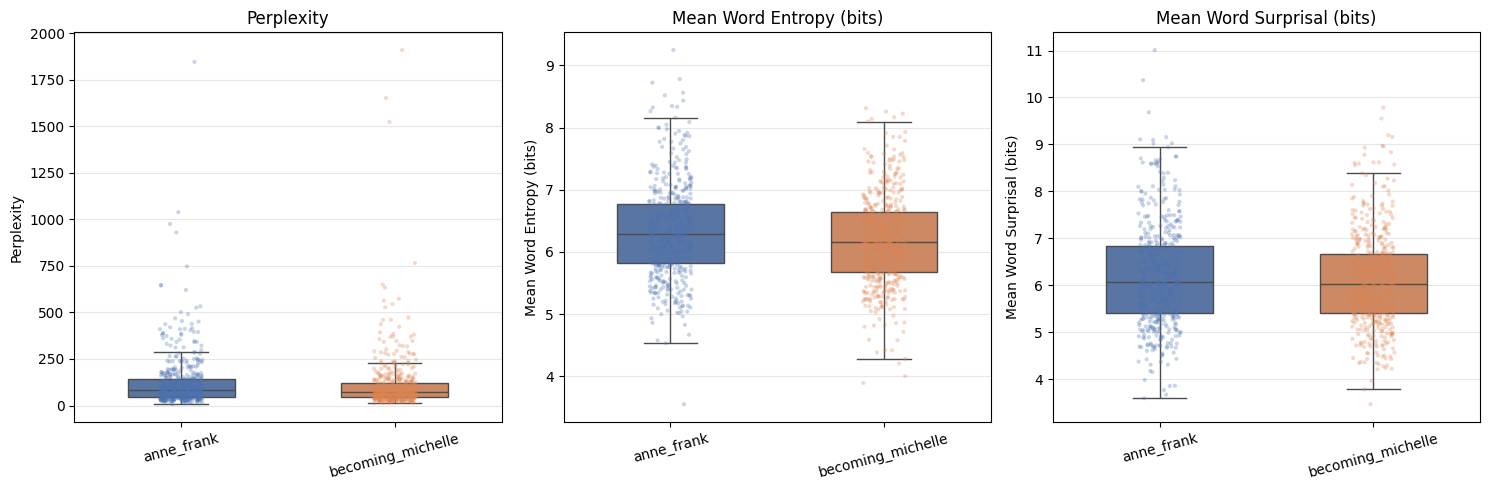

Saved: book_distribution_comparison.png


In [11]:
# ============================================================================
# PLOT 2: Distribution comparison (box + strip plot)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}
palette = [condition_colors[c] for c in ['anne_frank', 'becoming_michelle']]

for ax, metric, label in zip(axes, metrics_to_compare,
                              ['Perplexity', 'Mean Word Entropy (bits)', 'Mean Word Surprisal (bits)']):
    sns.boxplot(data=results_df, x='condition', y=metric, ax=ax,
                palette=palette, width=0.5, showfliers=False,
                order=['anne_frank', 'becoming_michelle'])
    sns.stripplot(data=results_df, x='condition', y=metric, ax=ax,
                  palette=palette, alpha=0.3, size=3, jitter=True,
                  order=['anne_frank', 'becoming_michelle'])
    ax.set_ylabel(label)
    ax.set_xlabel('')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('book_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: book_distribution_comparison.png")

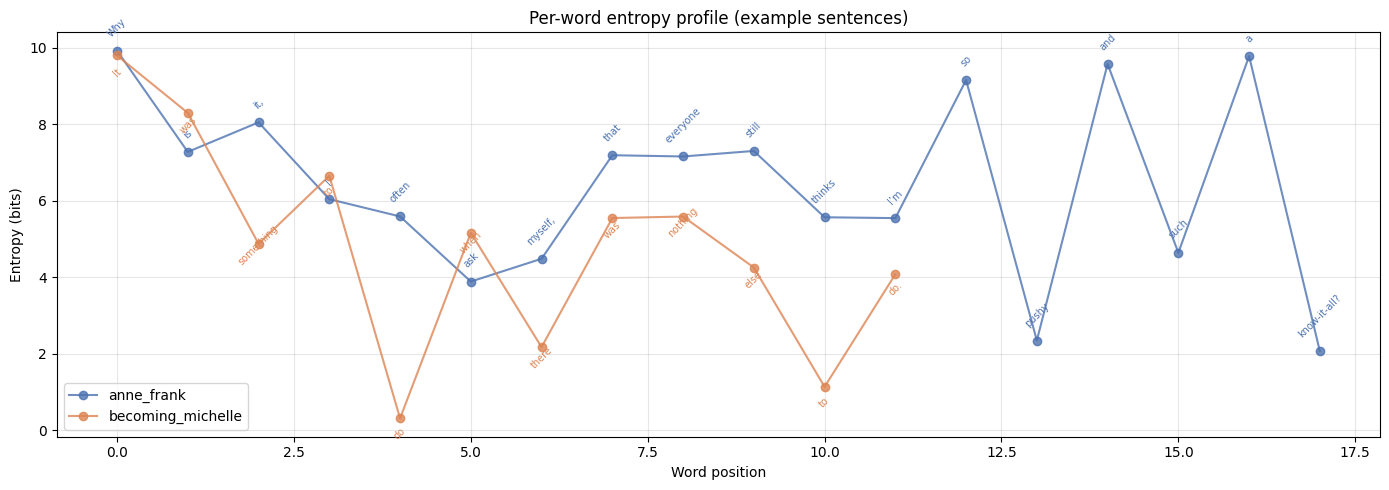

Saved: book_entropy_profile.png


In [12]:
# ============================================================================
# PLOT 3: Per-word entropy profile (example sentence from each condition)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

for condition, color in condition_colors.items():
    candidates = [item for item in corpus
                  if item['condition'] == condition and len(item['text'].split()) >= 8]
    if not candidates:
        continue
    item = candidates[0]
    m = process_text_full_metrics(model, tokenizer, item['text'])

    words = m['words']
    entropies = m['word_entropies']

    positions = range(len(entropies))
    ax.plot(positions, entropies, 'o-', color=color, label=condition, alpha=0.8)

    for pos, word, ent in zip(positions, words[:len(entropies)], entropies):
        offset_y = 10 if condition == 'anne_frank' else -15
        ax.annotate(word, (pos, ent), textcoords="offset points",
                   xytext=(0, offset_y),
                   ha='center', fontsize=7, color=color, rotation=45)

ax.set_xlabel('Word position')
ax.set_ylabel('Entropy (bits)')
ax.set_title('Per-word entropy profile (example sentences)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('book_entropy_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: book_entropy_profile.png")

---
## 9. Context Ablation

Context ablation (cue='to'):   0%|          | 0/1000 [00:00<?, ?it/s]

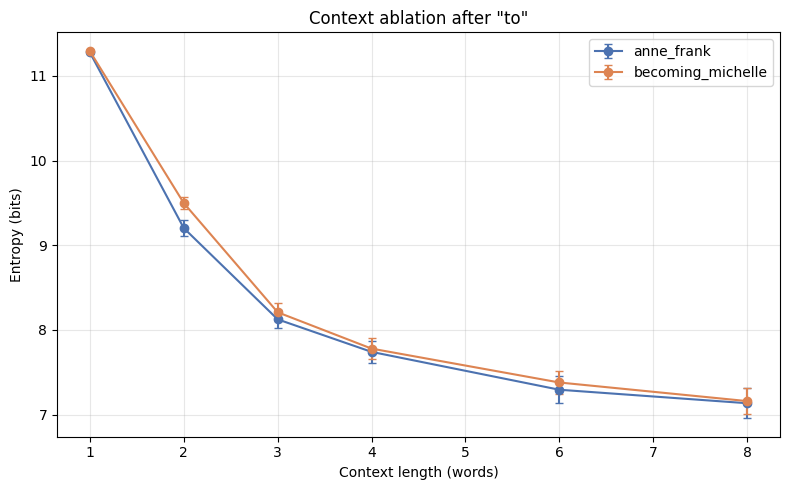

Saved: book_context_ablation.png


In [13]:
# ============================================================================
# CONTEXT ABLATION
# ============================================================================

def context_ablation(
    model, tokenizer, text: str, target_word_index: int,
    context_sizes: List[int] = None, target_words: Set[str] = None,
    device=DEVICE
) -> pd.DataFrame:
    words = text.split()
    if target_word_index >= len(words):
        raise ValueError(f"target_word_index {target_word_index} >= number of words {len(words)}")

    full_prefix_words = words[:target_word_index + 1]
    full_k = len(full_prefix_words)

    if context_sizes is None:
        context_sizes = []
        k = 1
        while k < full_k:
            context_sizes.append(k)
            k *= 2
        context_sizes.append(full_k)
        context_sizes = sorted(set(context_sizes))

    results = []
    for k in context_sizes:
        if k > full_k:
            continue
        context_words = full_prefix_words[-k:]
        context = ' '.join(context_words)
        inputs = tokenizer(context, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]
        probs = torch.softmax(logits, dim=-1)
        log_probs = torch.log2(probs + 1e-10)
        entropy = -(probs * log_probs).sum().item()
        row = {'k': k, 'context': context, 'entropy': entropy}
        if target_words is not None:
            mass = compute_class_mass(model, tokenizer, context, target_words, device=device)
            row['class_mass'] = mass
        results.append(row)

    return pd.DataFrame(results)


def find_word_position(text: str, target_word: str) -> Optional[int]:
    words = text.lower().split()
    target = target_word.lower()
    for i, w in enumerate(words):
        if w.strip('.,!?;:') == target:
            return i
    return None


CUE_WORD = 'to'
CONTEXT_SIZES = [1, 2, 3, 4, 6, 8]

all_ablation_results = []

for item in tqdm(corpus, desc=f"Context ablation (cue='{CUE_WORD}')"):
    text = item['text']
    pos = find_word_position(text, CUE_WORD)
    if pos is None:
        continue
    try:
        abl_df = context_ablation(
            model, tokenizer, text,
            target_word_index=pos,
            context_sizes=CONTEXT_SIZES,
            target_words=DEMO_VERBS
        )
        abl_df['condition'] = item.get('condition', 'unknown')
        all_ablation_results.append(abl_df)
    except Exception as e:
        continue

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

if all_ablation_results:
    ablation_full_df = pd.concat(all_ablation_results, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    for condition, color in condition_colors.items():
        subset = ablation_full_df[ablation_full_df['condition'] == condition]
        if len(subset) == 0:
            continue
        means = subset.groupby('k')['entropy'].mean()
        sems = subset.groupby('k')['entropy'].sem()
        ax.errorbar(means.index, means.values, yerr=sems.values,
                   fmt='o-', color=color, label=condition, capsize=3)

    ax.set_xlabel('Context length (words)')
    ax.set_ylabel('Entropy (bits)')
    ax.set_title(f'Context ablation after "{CUE_WORD}"')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('book_context_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: book_context_ablation.png")
else:
    print(f"No items contain the cue word '{CUE_WORD}'.")

---
## 10. Save Results

In [14]:
# ============================================================================
# SAVE ALL RESULTS
# ============================================================================

# Save main results as CSV
results_df.to_csv('book_comparison_results.csv', index=False)
print("Saved: book_comparison_results.csv")

# Save comparison statistics
if len(comp_df) > 0:
    comp_df.to_csv('book_statistical_comparisons.csv', index=False)
    print("Saved: book_statistical_comparisons.csv")

# Save ablation results
if all_ablation_results:
    ablation_full_df.to_csv('book_context_ablation_results.csv', index=False)
    print("Saved: book_context_ablation_results.csv")

# Save as JSON for programmatic reloading
results_json = results_df.to_dict(orient='records')
with open('book_comparison_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print("Saved: book_comparison_results.json")

print("\n" + "=" * 60)
print("All results saved successfully!")
print("=" * 60)

Saved: book_comparison_results.csv
Saved: book_statistical_comparisons.csv
Saved: book_context_ablation_results.csv
Saved: book_comparison_results.json

All results saved successfully!
